Àlgebra Lineal Numèrica - Óscar Rodríguez

# Pràctica 2: L' Equació de la calor estacionària

## Objectius:



*   Construir i programar de manera eficient el mètode de Jacobi per tal de resoldre un problema de calor estacionari.



## Introducció:

### L'equació de la calor

L'equació de la calor és una equació diferencial parcial (EDP) que relaciona la variació temporal i espacial de la temperatura en un medi. Matemàticament, aquesta equació ve donada per:

$$
\frac{\partial u}{\partial t} = k \Delta u + f
$$

on

* $u=u(\boldsymbol{x},t)$ representa la temperatura en el punt $\boldsymbol{x}$ del domini $\Omega$ a l'instant de temps $t$.

* $k$ denota la conductivitat tèrmica del material (propietat que descriu la seva capacitat per transmetre la calor).

* $\Delta$ és l'operador laplacià, que quantifica la variació espacial de la temperatura, el qual veurem més endavant.

* $f = f(\boldsymbol{x},t)$ és la funció font, que representa la generació de calor en el medi en cada punt $\boldsymbol{x}\in\Omega$ i en cada instant $t$.

Usualment $\Omega\subset\mathbb{R}^n$ amb $n=1,2,3$.

#### El Laplacià:

Formalment, l'operador Laplacià d'una funció escalar $u(\boldsymbol{x})$, on $\boldsymbol{x} = (x_1,x_2,\ldots,x_n)\in\mathbb{R}^n$ es defineix com la suma de les segones derivades de la funció $u$ respecte a cada una de les coordenades:

$$
    \Delta u = \frac{\partial^2 u}{\partial x_1^2} + \frac{\partial^2 u}{\partial x_2^2} +\ldots + \frac{\partial^2 u}{\partial x_n^2}.
$$

##### *Exemple:*

El laplacià de la funció $f(x_1,x_2) = x_1^2x_2^2 -\cos(x_1)$ ve donat per:

$$
    \Delta f(x_1,x_2) = \color{blue}{\frac{\partial^2 f}{\partial x_1^2}} + \color{red}{\frac{\partial^2 f}{\partial x_2^2}} = \color{blue}{2x_2^2 + \cos(x_1)} + \color{red}{2x_1^2} = 2(x_1^2+x_2^2) + \cos(x_1)
$$

#### El Laplacià en el context de l'equació de la calor

En el context  de l'equació de la calor, el Laplacià de la temperatura $u(\boldsymbol{x},t)$  descriu com la temperatura varia espacialment en un medi i, per tant, tindrem:

$$
    \Delta u (\boldsymbol{x},t) = \frac{\partial^2 u}{\partial x_1^2}(\boldsymbol{x},t) + \frac{\partial^2 u}{\partial x_2^2}(\boldsymbol{x},t) +\ldots + \frac{\partial^2 u}{\partial x_n^2}(\boldsymbol{x},t).
$$



#### El domini $\Omega$


El domini $\Omega$ representa la regió espacial en què s'està estudiant el comportament del sistema físic. És fonamental definir aquest domini amb precisió per tal de poder formular correctament el problema i trobar solucions significatives. El domini pot ser un subconjunt de l'espai $n$-dimensional on es desenvolupa el fenomen, així és típic considerar des de dominis unidimensionals fins a dominis tridimensionals, segons la naturalesa del problema.


Per tal de poder resoldre el problema de manera única és necessària imposar condicions de frontera al domini. Aquestes condicions fixen el comportament de la solució en els límits del domini $\Omega$, delimitant el problema i donant-li un sentit físic.
Hi ha diversos tipus de condicions de frontera que poden ser imposades, i la seva elecció depèn de la naturalesa del problema i de les seves característiques físiques.
Alguns dels tipus de condicions de frontera més comuns són:

* **Condicions de Dirichlet**: Aquestes condicions fixen el valor de la solució en els límits del domini $\Omega$. Matemàticament, es pot expressar com $u(x, t) = g(x, t)$, on $g(x, t)$ és una funció donada.
    
* **Condicions de Neumann**: Aquestes condicions fixen la derivada normal de la solució en els límits del domini $\Omega$. Matemàticament, es pot expressar com $\frac{\partial u}{\partial n}(x, t) = h(x, t)$, on $\frac{\partial u}{\partial n}$ és la derivada normal de $u$ i $h(x, t)$ és una funció donada.
    



&nbsp;

En aquesta pràctica únicament considerarem condicions de frontera de Dirichlet.


##### *Exemple*

Considerem el domini $\Omega = \{ (x_1,x_2)\in\mathbb{R}^2 \,:\, x_1^2+x_2^2 \leq 1\}$ i considerem les següents condicions a la frontera de $\Omega$, la qual denotarem per $\delta\Omega$:

* $u((x_1,x_2),t)=x$ per $\{x_1\geq 0\} \cap \delta\Omega$ i $\forall t$

* $u((x_1,x_2),t)=0$ per $\{x_1< 0\} \cap \delta\Omega$ i $\forall t$

Gràficament tindriem:

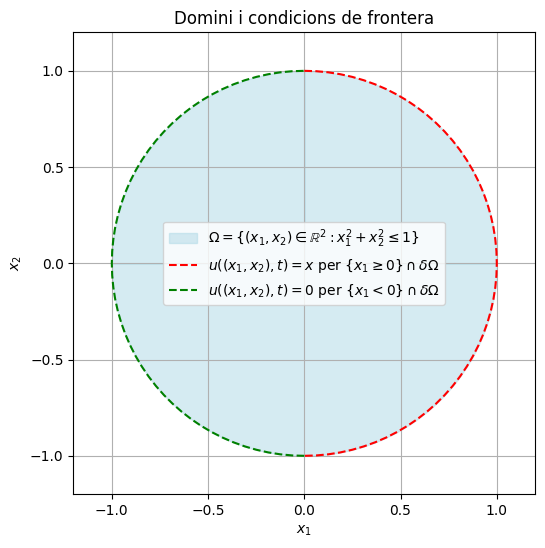

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definim el domini:
theta = np.linspace(0, 2 * np.pi, 101)
r = 1
x1 = r * np.sin(theta)
x2 = r * np.cos(theta)

# Creem la figura:
fig, ax = plt.subplots(figsize=(6, 6))

# Dibuixem el domini:
ax.fill_between(x1, x2, color="lightblue", alpha=0.5, label=r"$\Omega = \{(x_1, x_2) \in \mathbb{R}^2 : x_1^2 + x_2^2 \leq 1\}$")

# Condicions de frontera
ax.plot(x1[:51], x2[:51], color="red", linestyle="--", label=r"$u((x_1, x_2), t) = x$ per $\{x_1 \geq 0\} \cap \delta\Omega$")
ax.plot(x1[50:], x2[50:], color="green", linestyle="--", label=r"$u((x_1, x_2), t) = 0$ per $\{x_1 < 0\} \cap \delta\Omega$")

# Dibuixem els exios
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Domini i condicions de frontera")
ax.legend()
plt.grid(True)

# Mostrem el gràfic
plt.show()

&nbsp;

#### Condició inicial

Per tal de poder resoldre aquesta EDP necessitem un punt de partida, una condició inicial que ens denota la temperatura inicial al domini $\Omega$ en l'instant de temps $t_0$.

Normalment, notem aquesta condició per $u_{t_0}(\boldsymbol{x}) = u(\boldsymbol{x},t_0)$.

&nbsp;



#### El terme font

El terme font en l'equació de la calor és una funció que representa la font o la font d'energia que genera o absorbeix calor en un sistema. Aquest terme pot representar, per exemple, una font externa de calor com una font de calor que s'afegeix al sistema, o pot reflectir la generació interna de calor dins del mateix sistema.

En cas que no hi hagi terme font (és a dir, $f(\boldsymbol{x},t) \equiv 0 $) direm que l'equació de la calor és **homogènia**.

&nbsp;

#### Equació estacionària




L'equació de la calor estacionària descriu la distribució d'una quantitat de calor en un sistema quan aquest ha arribat a un estat d'equilibri tèrmic, és a dir, quan la temperatura en el sistema ja no canvia amb el temps. En aquest estat, la variació de la temperatura respecte al temps és zero en tot el domini del sistema.

**L'equació de la calor estacionària** es representa matemàticament com una equació en derivades parcials, que estableix l'equilibri entre la conducció de calor a través del material i les fonts de calor presents en el sistema. La forma més comuna de l'equació de la calor estacionària és:

$$
\Delta u = -F(\boldsymbol{x})
$$

&nbsp;

De la mateixa manera, en el cas que $F(\boldsymbol{x})\equiv 0$ estarem en el cas de l'equació de la calor **homogènia** i estacionària.

&nbsp;

### El mètode de les diferències finites

El mètode de les diferències finites és una tècnica numèrica utilitzada per resoldre equacions diferencials, incloent-hi equacions en derivades parcials. Consisteix a discretitzar l'espai i el temps del domini de la solució i aproximar les derivades en els punts de la xarxa de discretització mitjançant diferències finites.

&nbsp;

Ho veurem únicament pel cas de l'equació de la calor estacionària.

&nbsp;

#### Aproximació numèrica de derivades

Per aproximar numèricament les derivades de funcions utilitzant diferències finites, podem fer servir el desenvolupament de Taylor.

Recordem que si $f:\mathbb{R}\rightarrow\mathbb{R}$ és una funció, el seu desenvolupament de Taylor al punt $x_0$ ve donat per:

$$
f(x_0 + h) = f(x_0) + f'(x_0)h + \frac{f''(x_0)}{2!}h^2 + \frac{f'''(x_0)}{3!} h^3 + \mathcal{O}(h^4).
$$

I, anàlogament:

$$
f(x_0 - h) = f(x_0) - f'(x_0)h + \frac{f''(x_0)}{2!}h^2 - \frac{f'''(x_0)}{3!} h^3 + \mathcal{O}(h^4).
$$

&nbsp;

##### **Aproximació (centrada) de la primera derivada:**

Si a la primera equació li restem la segona, obtenim:

$$
\begin{aligned}
f(x_0 + h) - f(x_0-h) &= f(x_0) + f'(x_0)h + \frac{f''(x_0)}{2!}h^2 + \frac{f'''(x_0)}{3!} h^3 + \mathcal{O}(h^4)\\
&\hspace{3mm} - \left(f(x_0) - f'(x_0)h + \frac{f''(x_0)}{2!}h^2 - \frac{f'''(x_0)}{3!} h^3 + \mathcal{O}(h^4)\right)\\
& = 2f'(x_0)h + \mathcal{O}(h^3)
\end{aligned}
$$

I, dividint a banda i banda per $2h$, tenim l'aproximació centrada de la primera derivada:

$$
    f'(x_0) = \frac{f(x_0 + h) - f(x_0-h)}{2h} + \mathcal{O}(h^2)
$$


&nbsp;

##### **Aproximació de la segona derivada:**

Si sumem els dos desenvolupaments de Taylor anteriors, obtenim:

$$
\begin{aligned}
f(x_0 + h) + f(x_0-h) &= f(x_0) + f'(x_0)h + \frac{f''(x_0)}{2!}h^2 + \frac{f'''(x_0)}{3!} h^3 + \mathcal{O}(h^4)\\
&\hspace{3mm} + \left(f(x_0) - f'(x_0)h + \frac{f''(x_0)}{2!}h^2 - \frac{f'''(x_0)}{3!} h^3 + \mathcal{O}(h^4)\right)\\
& = 2f(x_0) +  f''(x_0)h^2 + \mathcal{O}(h^4).
\end{aligned}
$$

Aïllant $f''(x_0)$ arribem a:

$$
f''(x_0) = \frac{f(x_0 + h)- 2f(x_0) + f(x_0-h)}{h^2} + \mathcal{O}(h^2)
$$

&nbsp;


**Observació:** Fixem-nos que les dues aproximacions que hem obtingut són d'ordre $h^2$.

&nbsp;

##### **Aproximació numèrica del Laplacià:**

Si considerem ara la funció $g:\Omega \subset \mathbb{R}^n \rightarrow \mathbb{R}$ i volem calcular el seu Laplacià, podem utilitzar l'aproximació de la segona derivada que hem vist anteriorment:

$$
    \Delta g(\boldsymbol{x}) = \sum_{i=1}^n \frac{\partial^2 g(\boldsymbol{x})}{\partial x_i^2} \approx \sum_{i=1}^n \frac{g(\boldsymbol{x} + h_i \boldsymbol{e}_i)- 2g(\boldsymbol{x}) + g(\boldsymbol{x} - h_i \boldsymbol{e}_i)}{h_i^2}
$$

on $\boldsymbol{e}_i$ amb $i=1,\ldots,n$ són els vectors de la base canònica i $h_i$ són quantitats prou petites.

&nbsp;

Fixem-nos que pel cas de $h_1=h_2 = \ldots = h_n= h$ podem reescriure l'aproximació del Laplacià com:

$$
    \Delta g(\boldsymbol{x}) \approx - \frac{2n g(\boldsymbol{x})}{h^2} + \sum_{i=1}^n \frac{g(\boldsymbol{x} + h \boldsymbol{e}_i) + g(\boldsymbol{x} - h \boldsymbol{e}_i)}{h^2}
$$

&nbsp;



#### Mètode de les diferències finites: Cas 1D

El mètode de les diferències finites és una tècnica numèrica utilitzada per aproximar solucions d'equacions diferencials mitjançant el càlcul de les derivades de manera discreta. Veiem aquest mètode aplicat a l'equació de la calor estacionària pel cas d'intervals 1-dimensionals amb condicions de frontera de Dirichlet.

Així doncs, matemàticament el problema que tenim és determinar la funció $u(x)$ que satisfà:

$$
\left\{
    \begin{aligned}
        &u_{xx}(x) = - F(x),\quad \text{ per } x\in[a,b]\\
        &u(a) = c_a,\\
        &u(b) = c_b.
    \end{aligned}
\right.    
$$

on $u_{xx}(x)$ denota la segona derivada de $u(x)$ (i, per tant, $\Delta u(x) = u_{xx}(x)$ pel cas 1-dimensional) i $c_a$ i $c_b$ són constants.

&nbsp;

##### **Discretització del domini**

En el cas 1D, considerem una funció $u(x)$ definida en un interval $[a,b]$, on $x$ és la variable independent.

El primer que farem serà dividir l'interval $[a, b]$ en $N$ punts equidistants, creant $N+1$ nodes $x_i$ amb $i = 0, 1, 2, ..., N$.
Denotarem la distància entre dos nodes consecutius com $h$, la qual podem calcular fàcilment com $h = \cfrac{b-a}{N}$.

##### **Equació punt a punt**


Per aproximar la segona derivada de la funció $u(x)$ en un punt $x_i$, utilitzarem la fórmula de diferències finites vista anteriorment.
Notant $u_i = u(x_i)$, tenim:

$$
\Delta u_i \approx \frac{u_{i+1}- 2u_i + u_{i-1}}{h^2}
$$

de la mateixa manera, notarem per $F_i = F(x_i)$. D'aquesta manera, per $i=1,\ldots,N-1$, tenim:

$$\frac{u_{i+1} - 2u_i + u_{i-1}}{h^2} = -F_i$$

o, anàlogament,

$$u_{i+1} - 2u_i + u_{i-1} = -h^2F_i$$.

on els $u_i$ per $i=1,\ldots,N-1$ són les incògnites a determinar.

##### **Sistema lineal associat**

Fixem-nos que les equacions anteriors ens determinen un sistema lineal de la forma:

$$
\left\{
    \begin{aligned}
    &u_0 = c_a,\\
    &u_{i-1} - 2u_i + u_{i+1} = -h^2F_i,\quad \text{ per } i = 1,\ldots, N-1\\
    &u_N = c_b.
    \end{aligned}
\right.    
$$

o, com ja tenim determinats $u_0$ i $u_N$, podem escriure:

$$
\left\{
    \begin{aligned}
    - 2u_1 + u_{2} &= -h^2F_1 - u_{0}\\
    u_{i-1} - 2u_i + u_{i+1} &= -h^2F_i,\qquad \text{ per } i = 2,\ldots, N-2\\
    u_{N-2}- 2u_{N-1} &= -h^2F_{N-1} - u_{N}\\.
    \end{aligned}
\right.    
$$


El qual, podem escriure en forma matricial de la següent forma:

$$
\begin{pmatrix}
 -2 & 1 &  \\
  1 &-2 & 1 &  \\
    & 1 &-2 & 1 &  \\
   &   & \ddots & \ddots & \ddots\\
   & & & \ddots & \ddots & \ddots\\
   & & &  & \ddots & \ddots & \ddots\\
   & & &  & & 1 & -2 & 1\\
   & & &  & & & 1 & -2 \\
\end{pmatrix}
\begin{pmatrix}
u_1\\
u_2\\
u_3\\
\vdots\\
\vdots\\
\vdots\\
u_{N-2}\\
u_{N-1}
\end{pmatrix}
=
\begin{pmatrix}
-h^2F_1 - u_{0}\\
-h^2F_2\\
-h^2F_3\\
\vdots\\
\vdots\\
\vdots\\
-h^2F_{N-2}\\
-h^2F_{N-1} - u_{N}\\
\end{pmatrix}
$$

&nbsp;

És a dir tenim un sistema tridiagonal que podem resoldre fàcilment.

&nbsp;

##### *Exemple: Cas equació homogènica estacionària*

*L'objectiu de la pràctica serà resoldre aquest tipus de sistemes utilitzant el mètode iteratiu de Jacobi, tenint en compte que la majoria d'elements són $0$, és a dir evitant operacions innecessàries.*

*Fixem-nos primer de tot que no és una bona idea construir la matriu del sistema, ja que si $N$ és prou gran estarem utilitzant molta memòria innecesàriament:*

In [ ]:
## Suposem N = 10000 construim la matriu i veiem la seva mida en bytes:
import numpy as np
from sys import getsizeof

N = 10000

# Matriu del sistema:
A = np.eye(N-1,k=1)-2*np.eye(N-1)+np.eye(N-1,k=-1)

# Mida en bytes:
getsizeof(A) # 800 MB!!

# La borrem millor...
del(A)

&nbsp;

*Ens restringirem ara únicament a l'equació de la calor estacionària homogènia pel cas 1D, és a dir, l'equació $u_{xx} = 0$. Notem que aquesta equació té solució trivial, ja que és la recta que passa per $u(a) = c_a$ i $u(b)=c_b$, però ens servirà per veure com podem fer un codi eficient per tal de resoldre-la numèricament utilitzant el mètode de Jacobi.*

*En aquest primer cas, una iteració de Jacobi es redueix a:*

$$
u_i^{(k+1)} = \frac{u_{i-1}^{(k)} + u_{i+1}^{(k)}}{2}\qquad \text{per } i=1,\ldots,N-1.
$$

*La primera idea que podem tenir és anar actualitzant terme a terme:*

Temps total: 0.616837 segons


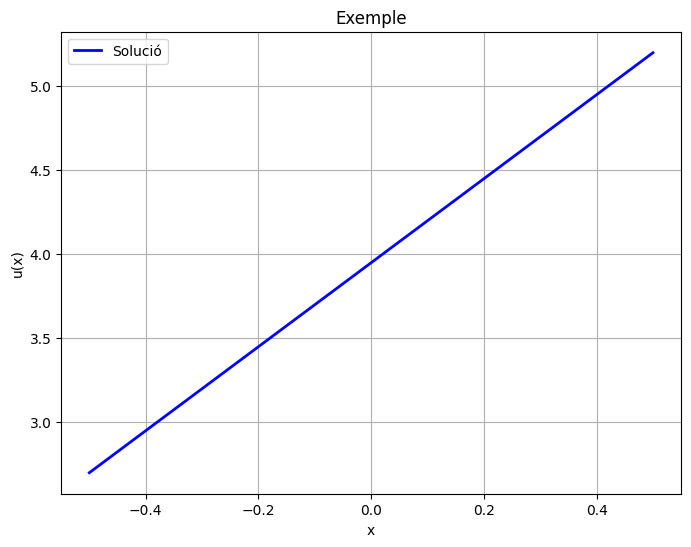

In [ ]:
## Primera aproximació:
import numpy as np
import matplotlib.pyplot as plt
import time

# Definim a = -0.5 i b = 0.5
a = -0.5
b = 0.5

# Condicions de frontera:
cA = 2.7
cB = 5.2

# N = 100:
N = 100

# Com és una equació homogènia no cal definir h
# h = (b-a)/N

# Inicialitzem el vector u amb el promig de la frontera i imposem als extrems
umean = (cA+cB)/2
u = umean*np.ones(N+1)
u[0] = cA
u[N] = cB

##############################################################################
# Anem a fer 10000 iteracions del mètode:

# Temps inicial:
inici = time.time()

# Iterem:
for k in range(10000):
    for i in range(1,N):
        u[i] = (u[i-1]+u[i+1])/2

# Temps final:
fi = time.time()

# Temps total:
temps_total = fi - inici

# Printem el temps necessari:
print(f"Temps total: {temps_total:.6f} segons")


##############################################################################
# Dibuixem la solució:

# Malla equiespaiada:
x = np.linspace(a,b,N+1)

# Obrim la Figura i dibuixem:
plt.figure(figsize=(8, 6))

# Plot:
plt.plot(x, u, label="Solució", color="b", linewidth=2)

# Eixos i llegenda
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Exemple")
plt.grid(True)
plt.legend()

# Mostrem el dibuix:
plt.show()

&nbsp;

*Fixem-nos que podem reduïr el temps d'execució del programa anterior utilitzant les operacions vectoritzades de python.*


Temps total: 0.039596 segons


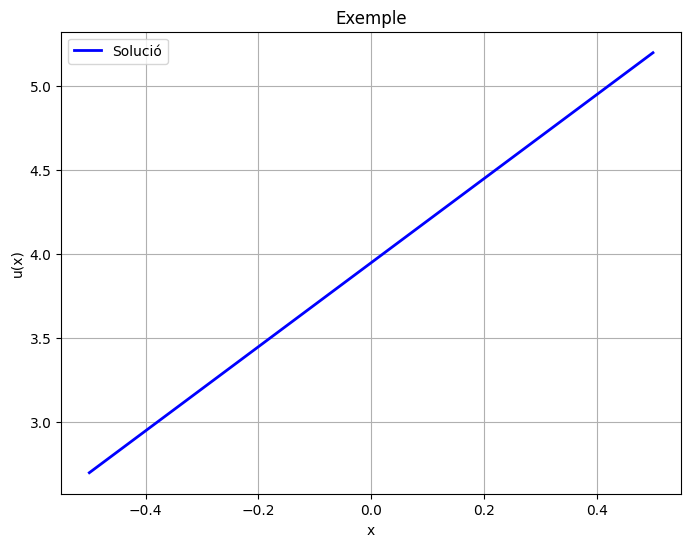

In [ ]:
## Segona aproximació:
import numpy as np
import matplotlib.pyplot as plt
import time

# Definim a = -0.5 i b = 0.5
a = -0.5
b = 0.5

# Condicions de frontera:
cA = 2.7
cB = 5.2

# N = 100:
N = 100

# Com és una equació homogènia no cal definir h
# h = (b-a)/N

# Inicialitzem el vector u amb el promig de la frontera i imposem als extrems
umean = (cA+cB)/2
u = umean*np.ones(N+1)
u[0] = cA
u[N] = cB


##############################################################################
# Anem a fer 10000 iteracions del mètode:

# Temps inicial:
inici = time.time()

# Iterem:
for k in range(10000):
    u[1:N] = (u[:N-1]+u[2:])/2 # També podem escriure: (u[:-2]+u[2:])/2

# Temps final:
fi = time.time()

# Temps total:
temps_total = fi - inici

# Printem el temps necessari:
print(f"Temps total: {temps_total:.6f} segons")



##############################################################################
# Dibuixem la solució:

# Malla equiespaiada:
x = np.linspace(a,b,N+1)

# Obrim la Figura i dibuixem:
plt.figure(figsize=(8, 6))

# Plot:
plt.plot(x, u, label="Solució", color="b", linewidth=2)

# Eixos i llegenda
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Exemple")
plt.grid(True)
plt.legend()

# Mostrem el dibuix:
plt.show()

&nbsp;

*Tot i que sigui un exemple de joguina el temps d'execució és significativament més petit.*

&nbsp;

#### Mètode de les diferències finites: Cas 2D

Considerem ara que el problema que tenim és determinar la funció $u(x)$ que satisfà:

$$
\left\{
    \begin{aligned}
        &\Delta u(x,y) = - F(x,y),\quad \forall (x,y)\in \Omega \subset \mathbb{R}^2\\
        &u(x,y) = g(x,y), \quad \forall (x,y) \in \delta\Omega
    \end{aligned}
\right.    
$$

##### **Discretització del domini**

De la mateix manera que pel cas 1D, el primer pas serà discretitzar el domini $\Omega$. En aquest cas, ho farem en punts $(x_i,y_j)$.

Observem però que aquest mètode ja presenta certes limitacions, ja que per qualsevol node $(x_i,y_j)$ que pertanyi a l'interior del domini $\Omega$, necessitem que els seus nodes adjacents (és a dir, els nodes $(x_{i+1},y_{j})$, $(x_{i-1},y_{j})$, $(x_{i},y_{j+1})$ i $(x_{i},y_{j-1})$ pertanyin a $\Omega$). Això, depenent del domini no és fàcil d'aconseguir (com per exemple en el cas anterior on teníem $\Omega = \{(x,y)\in \mathbb{R}^2\,:\,x^2+y^2\leq 1\}$).

Ara bé, per certs dominis poligonals això sí que és possible d'aconseguir, sense la necessitat de treballar amb malles molt grolleres. (El cas anterior es pot aconseguir considerant només 5 nodes, però la qualitat de la solució serà extremadament dolenta).

Veiem un exemple per tal d'entendre millor la idea:



###### *Exemple: Mallat d'un rectangle*

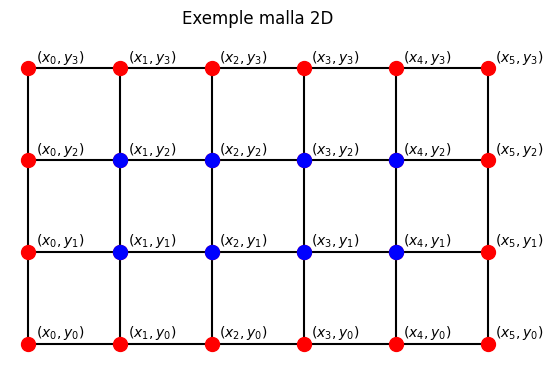

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Creem una malla de 6 x 4 punts
x_points = 6
y_points = 4
x_coords = np.linspace(0, 2.5, x_points)
y_coords = np.linspace(0, 1.5, y_points)

# Creem la figura
fig, ax = plt.subplots()

# Dibuixem les arestes entre els nodes adjacents
for i in range(x_points):
    for j in range(y_points - 1):
        ax.plot([x_coords[i], x_coords[i]], [y_coords[j], y_coords[j + 1]], 'k-')  # Arestes verticals

for i in range(x_points-1):
    for j in range(y_points):
        ax.plot([x_coords[i], x_coords[i + 1]], [y_coords[j], y_coords[j]], 'k-')  # Arestes horitzontals


# Dibuixem els nodes:
for i in range(x_points):
    for j in range(y_points):
        ax.plot(x_coords[i], y_coords[j], 'ro', markersize=10)  # Nodes en vermell
        ax.text(x_coords[i] + 0.04, y_coords[j] + 0.04, f'$(x_{i},y_{j})$', fontsize=10)  # Etiqueta (x_i,y_j)

# Tornem a dibuixar els nodes interiors:
for i in range(1,x_points-1):
    for j in range(1,y_points-1):
        ax.plot(x_coords[i], y_coords[j], 'bo', markersize=10)  # Nodes interiors en blau


# Limits, aspecte i títol:
ax.set_aspect('equal')
ax.set_xlim(-0.1, 2.6)
ax.set_ylim(-0.1, 1.7)
plt.title('Exemple malla 2D')
plt.axis('off')

# Mostrem el dibuix:
plt.show()



*Fixem-nos que tots els nodes interiors (en blau) tenen presents els seus quatre nodes adjacents. Així doncs, en aquest cas, podríem utilitzar el mètode de diferències finites.*

&nbsp;

*Observem també que, en aquest cas tenim els $x_i$ amb $i=0,...,N$ (amb $N=5$) i $y_j$ amb $j=0,...,M$ (amb $M=3$). I, si tinguéssim que $\Omega = [a,b]\times[c,d]$ tindriem que $h_1 = \cfrac{b-a}{N}$ i $h_2 = \cfrac{d-c}{M}$.*

&nbsp;

##### **Equació punt a punt**

Tot i que l'equació a cada node interior es podria escriure per qualsevol $h_1$ i $h_2$, ens limitarem al cas $h=h_1=h_2$.

Per aproximar la segona derivada de la funció $u(x,y)$ en un punt $(x_i,y_j)$, utilitzarem la fórmula de diferències finites vista anteriorment.
Notant $u_{i,j} = u(x_i,y_j)$, tenim:

$$
\Delta u_{i,j} \approx \frac{u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j}}{h^2}
$$

de la mateixa manera, notarem per $F_{i,j} = F(x_i,y_j)$. D'aquesta manera, pels nodes $(x_i,y_j)$ interiors, tindríem:

$$\frac{u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j}}{h^2} = -F_{i,j}$$

o, anàlogament,

$$u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j} = -h^2F_{i,j}$$.

on els $u_{i,j}$ són les incògnites a determinar.

&nbsp;

Fixem-nos que, en el cas del mètode de Jacobi, per cada node interior $(x_i,y_j)$ tenim:

$$
    u_{i,j}^{(k+1)} = \frac{u_{i+1,j}^{(k)} + u_{i-1,j}^{(k)} + u_{i,j+1}^{(k)} + u_{i,j-1}^{(k)} + h^2F_{i,j}}{4}
$$

&nbsp;

&nbsp;

# Enunciat pràctica:

### **Exercici 1:**

*Implementeu una funció que, donat els valor de l'interval $[a,b]$, els valors de la solució a la frontera $c_a$ i $c_b$, un valor de $N$, una funció $F$, un valor optatiu de la tolerància `tol` i un número màxim d'iteracions `maxIter`, resolgui l'equació estacionària 1D*

$$
\left\{
    \begin{aligned}
        &u_{xx}(x) = - F(x),\quad \text{ per } x\in[a,b]\\
        &u(a) = c_a,\\
        &u(b) = c_b.
    \end{aligned}
\right.    
$$

*utilitzant el mètode de Jacobi i les operacions vectoritzades de python.*

&nbsp;

*La funció ha de ser de l'estil:*

```
solEstEq1D(a, b, ca, cb, N, F, maxIter, tol)
```

&nbsp;

*Tingues en compte les següents consideracions:*

* *`tol` ens indicarà la tolerància mínima amb la qual volem la solució utilitzant la norma del màxim: $\|\boldsymbol{x}^{(k+1)}-\boldsymbol{x}^{(k)}\|_\infty < \varepsilon$. Un cop assolida, el mètode ha de retornar la solució.*

* *Preneu $u_i^{(0)} = (c_a+c_b)/2$ per $i=1,\ldots,N-1$.*

&nbsp;

*A més, la funció ha de retornar la solució `x` obtinguda i el nombre d'iteracions realitzades. Si no s'ha assolit la tolerància en el nombre màxim d'iteracions el valor del nombre d'iteracions realitzades s'ha de retornar amb signe negatiu. ës a dir, la funció retornarà sempre `u` solució i `niter` (nombre d'iteracions) .*

In [ ]:
#### Espai per la implementació de l'exercici 1:
import numpy as np

def norm_max(vector):
    return np.max(np.abs(vector))

def solEstEq1D(a, b, ca, cb, N, F, maxIter, tol):
    h = (b - a) / N

    #Inicialización de u
    umean = (ca+cb)/2
    u = umean*np.ones(N+1)
    u[0] = ca
    u[N] = cb

    # Vector de términos independientes
    B = np.zeros(N + 1)
    for i in range(1, N):
      B[i] = -(h**2) * F(a + h*i)

    # Método de Jacobi
    iter = 0
    error = 1
    u_new = np.zeros(N + 1)
    while error >= tol:
        iter += 1
        u_new[1:N] = (u[2:] + u[:N-1] - B[1:N]) / 2
        error = norm_max(u_new[1:N] - u[1:N])
        u[1:N] = np.copy(u_new[1:N])

    if iter <= maxIter:
        return u, iter, error
    else:
        return u, -iter, error


&nbsp;

*Aplica el codi anterior per resoldre el problema:*

$$
\left\{
    \begin{aligned}
        &u_{xx}(x) = - \sin(x),\quad \text{ per } x\in[0,\pi]\\
        &u(0) = 0,\\
        &u(\pi) = 1.
    \end{aligned}
\right.    
$$

&nbsp;

In [ ]:
#### Espai per fer l'aplicació de l'exercici 1:
def F(x):
    return np.sin(x)

a = 0
b = np.pi
ca = 0
cb = 1
N = 100
maxIter = 100
tol = 1.e-10

u, iter, error = solEstEq1D(a, b, ca, cb, N, F, maxIter, tol)

print(f"El u solución que buscamos es:\n {u}\n Lo hemos encontrado en {iter} iteraciones, con una tolerancia de {error}.")

El u solución que buscamos es:
 [0.         0.04141334 0.08279567 0.12411603 0.16534352 0.2064473
 0.24739669 0.28816114 0.32871029 0.369014   0.40904235 0.44876571
 0.48815476 0.52718048 0.56581423 0.60402775 0.6417932  0.67908318
 0.71587076 0.7521295  0.78783348 0.82295734 0.85747629 0.89136612
 0.92460327 0.9571648  0.98902844 1.02017261 1.05057646 1.08021984
 1.10908337 1.13714843 1.1643972  1.19081265 1.21637858 1.24107963
 1.26490129 1.28782993 1.30985277 1.33095797 1.35113455 1.37037248
 1.38866263 1.40599683 1.42236785 1.43776938 1.4521961  1.46564365
 1.47810861 1.48958857 1.50008205 1.50958857 1.51810861 1.52564365
 1.5321961  1.53776938 1.54236785 1.54599683 1.54866263 1.55037248
 1.55113455 1.55095797 1.54985277 1.54782993 1.54490129 1.54107963
 1.53637858 1.53081265 1.5243972  1.51714843 1.50908337 1.50021984
 1.49057646 1.48017261 1.46902844 1.4571648  1.44460327 1.43136612
 1.41747629 1.40295734 1.38783348 1.3721295  1.35587076 1.33908318
 1.3217932  1.30402775 1.285814

**Et pot ser d'ajuda:**

Podem passar una funció com a argument d'una funció:

In [ ]:
# Exemple:
import numpy as np

# Definim la funció
def funcio(x):
    return x*x

# Funció que té com a argument una funció:
def evalVector(func,xs):
    n = len(xs)
    fxs = np.zeros(n,dtype=np.float64)
    for i in range(n):
        fxs[i] = func(xs[i])
    return fxs


# Codi:
xs = np.linspace(0,1,6)
fxs = evalVector(funcio,xs)

print(fxs)

[0.   0.04 0.16 0.36 0.64 1.  ]


&nbsp;

&nbsp;

### **Exercici 2:**

**Objectiu:** Calcular la temperatura mitjana de l'aula PC2 utilitzant un model 2 dimensional de l'FME.

**Problema:**

Suposem que després d'un matí de ple estiu i amb un Sol radiant, s'ha cobert el cel. Per l'orientació de l'FME ([vegeu el següent link](https://app.shadowmap.org/?lat=41.38326&lng=2.11627&zoom=17.56&azimuth=0.00000&basemap=map&elevation=nextzen&f=29.0&hud=true&polar=0.52360&time=1713154453580&vq=2)) hi ha parets que s'escalfaràn més que altres.

En particular, tenim que les parets orientades cap al carrer de Llorens i Artigas ($\Gamma_C$ i $\Gamma_c$ del dibuix posterior) seran les que més s'escalfin, seguides de les parets orientades cap al carrer de Pascual i Vila ($\Gamma_D$ i $\Gamma_d$). Per contra, les parets orientades cap al carrer de Pau Gargallo ($\Gamma_A$ i $\Gamma_a$) i el carrer d'Adolf Florensa ($\Gamma_B$ i $\Gamma_b$) estaran més fredes.



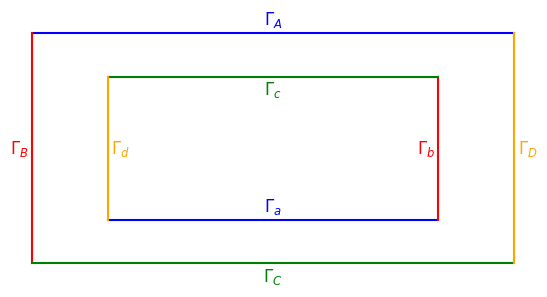

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Dibuixem:
fig, ax = plt.subplots()

# Parets exteriors
ax.plot([0, 134], [64, 64], color="blue")
ax.plot([0, 0], [0, 64], color="red")
ax.plot([0, 134], [0, 0], color="green")
ax.plot([134, 134], [0, 64], color="orange")

# Parets interiors
ax.plot([21, 113], [12, 12], color="blue")
ax.plot([113, 113], [12, 52], color="red")
ax.plot([21, 113], [52, 52], color="green")
ax.plot([21, 21], [12, 52], color="orange")



# Les etiquetem:
plt.text(67, 65, '$\Gamma_A$', fontsize=12, color='blue', ha='center', va='bottom')
plt.text(-1, 32, '$\Gamma_B$', fontsize=12, color='red', ha='right', va='center')
plt.text(67, -1, '$\Gamma_C$', fontsize=12, color='green', ha='center', va='top')
plt.text(135, 32, '$\Gamma_D$', fontsize=12, color='orange', ha='left', va='center')
plt.text(67, 13, '$\Gamma_a$', fontsize=12, color='blue', ha='center', va='bottom')
plt.text(112, 32, '$\Gamma_b$', fontsize=12, color='red', ha='right', va='center')
plt.text(67, 51, '$\Gamma_c$', fontsize=12, color='green', ha='center', va='top')
plt.text(22, 32, '$\Gamma_d$', fontsize=12, color='orange', ha='left', va='center')


# Limits i aspecte
plt.xlim(-2, 136)
plt.ylim(-2, 66)
plt.axis('off')  # Ocultem els eixos
ax.set_aspect('equal', adjustable='box') # mateixa escala eix x i eix y

# Dibuixem
plt.show()

Sabem que les parets de la FME són d'un material que reté molt bé la calor, volem saber quina serà la temperatura estacionària. En particular, l'objectiu, és determinar quina serà la temperatura mitjana estacionària de l'aula PC2.

Per esbrinar-la, primer haureu de resoldre la següent equació homogènia estacionària

$$
\left\{
\begin{aligned}
&\Delta u(\boldsymbol{x}) = 0,\quad \forall \boldsymbol{x}\in \Omega\\
& u(\boldsymbol{x}) = T_a,\quad \forall \boldsymbol{x}\in \Gamma_A \cup \Gamma_a\\
& u(\boldsymbol{x}) = T_b,\quad \forall \boldsymbol{x}\in \Gamma_B \cup \Gamma_b\\
& u(\boldsymbol{x}) = T_c,\quad \forall \boldsymbol{x}\in \Gamma_C \cup \Gamma_c\\
& u(\boldsymbol{x}) = T_d,\quad \forall \boldsymbol{x}\in \Gamma_D \cup \Gamma_d\\
\end{aligned}
\right.
$$

tot utilitzant el mètode del gradient per resoldre el problema de diferències finites. $T_a$, $T_b$, $T_c$ i $T_d$ són constants que dependran del problema i que trobareu especificades al fitxer TemperaturaVora.pdf a Atenea.

&nbsp;

La malla de punts que haureu d'utilitzar ha de ser de $(N+1) \times (M+1)$ punts equiespaitas, amb $N = 268$ i $M = 128$, de manera que l'increment $h$ que considereu és de $0.5\, m$, ja que les dimensions aproximades de l'FME són de $134\,m$ en el seu cantò llarg i $64\,m$ en el seu cantó curt. Tot i que hi haurà nodes (aquells que es troben al patí) que no serà necessari considerar, ja que només ens interessa la temperatura a l'interior de l'edifici.


&nbsp;

Teniu la resta de mesures necessàries per solucionar el problema al fitxer PC2-FME.pdf a Atenea.

&nbsp;

Observem que hi haurà nodes $(x_i,y_j)$ que estaran a més d'una frontera (per exemple el node $(x_0,y_0)$). En aquest cas el seu valor serà la mitjana entre les temperatures de les parets a les quals pertany. És a dir, si el node $(x_i,y_j)\in \Gamma_p \cap \Gamma_q$ aleshores $u(x_i,y_j) = (T_p+T_q)/2$.

&nbsp;

Com a condició inicial $u_{ij}^{(0)}$ prendrem la mitjana de la temperatura dels nodes a la frontera (els quals inicialitzarem amb el seu valor fixat).

&nbsp;

Finalment, utilitzarem com a criteri de convergència del mètode del gradient la condició:

$$
    \max_{i,j} |u_{ij}^{(k+1)} -u_{ij}^{(k)}| < 10^{-10}.
$$

&nbsp;

Un cop resolta l'equació haureu de determinar la temperatura mitjana de l'aula PC2 calculant la mitjana de temperatura dels nodes que es troben a l'aula PC2 (és a dir, haureu de fer la mitjana dels valors $u_{ij}$ tals que $(x_i,y_j)$ pertanyin a l'aula PC2, incloent les fronteres).

&nbsp;

Us pot ser d'ajuda el següent codi per tal de visualitzar la solució, (suposant que $u$ és una matriu de dimensions $(N+1) \times (M+1)$ con cada $u_{ij}$ ($i\in\{0,\ldots,N\}$, $j\in\{0,\ldots,M\}$) conté la temperatura al node $(x_i,y_j)$:

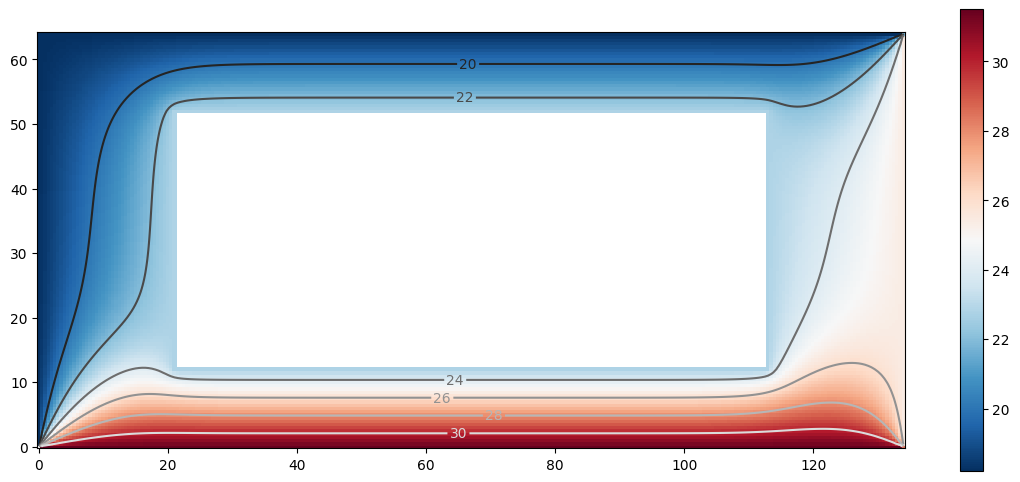

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Suposem:
N = 268
M = 128

# Generem la malla de punts on dibuixarem la solució:
X = np.linspace(0, 134, num=N+1)
Y = np.linspace(0, 64, num=M+1)
X, Y = np.meshgrid(X, Y)

# Asignem nan a la solució que està als nodes del pati per no dibuixar-la
U[43:226,25:104] = np.nan

# Dibuixem:
# Creem la figura:
fig, ax = plt.subplots(figsize=(14, 6))

# Mapa de colors:
plot = ax.pcolor(X, Y, U.T, cmap='RdBu_r')

# Corbes de Nivell:
cset = ax.contour(X, Y, U.T, cmap='gray')
plt.clabel(cset, inline=True)

# Ajustem la relació x i y perque sigui a escala
ax.set_aspect('equal', adjustable='box')

# Afegim la barra de colors
plt.colorbar(plot)

# Dibuixem el resultat:
plt.show()

&nbsp;

Podeu fer l'exercici a continuació:



In [27]:
#### Espai per fer l'exercici
import numpy as np

N = 268
M = 128

TA = 18.2
TB = 18.2
TC = 31.5
TD = 25.4

U = np.full((N+1,M+1),np.nan) #matriz de nan
U[1:N,128] = TA
U[0,1:M] = TB
U[1:N,0] = TC
U[268,1:M] = TD
U[0,128] = (TA+TB)/2
U[0,0] = (TB+TC)/2
U[268,0] = (TC+TD)/2
U[268,128] = (TA+TD)/2

U[43:226,20] = TA
U[226,21:104] = TB
U[43:226,104] = TC
U[42,21:104] = TD
U[226,20] = (TA+TB)/2
U[226,104] = (TB+TC)/2
U[42,104] = (TC+TD)/2
U[42,20] = (TA+TD)/2

media_fronteras = np.nanmean(U)
U[np.isnan(U)] = media_fronteras
U[43:226,25:104] = 0
U_patio = np.copy(U[42:227,24:105])

#Método de Jacobi
tol = 1.e-10
norma = 10
iter = 0
while norma >= tol:
  iter += 1
  U0 = U.copy()
  U[1:N,1:M] = ( U0[2:,1:M] # elementos u_i+1,j
               + U0[:-2,1:M] # elementos u_i-1,j
               + U0[1:N,2:] # elementos u_i,j+1
               + U0[1:N,:-2])/4 # elementos u_i,j-1

  U[42:227,24:105] = np.copy(U_patio)
  norma = np.max(np.abs(U-U0))

print(f"Hemos encontrado la solución en {iter} iteraciones, y la tolerancia es {norma}")

# Nodos pertenecientes a la PC2
submatriz = U[0:18, 20:51]

# Calcula la media de los elementos en esta submatriz
media = np.mean(submatriz)

print("La temperatura media es:", media)

Hemos encontrado la solución en 11450 iteraciones, y la tolerancia es 9.985967608372448e-11
La temperatura media es: 20.347803706122626
